In [11]:
import mne
from mne.preprocessing import ICA
import matplotlib.pyplot as plt
from mne.datasets import eegbci

### Importing data

In [12]:
file_path = "dataset/S001/S001R04.edf"

print(f"Loading {file_path}...")

raw = mne.io.read_raw_edf(file_path, preload=True)

print("\n--- EEG Metadata ---")
print(f"Number of channels: {len(raw.ch_names)}")
print(f"Sampling frequency: {raw.info['sfreq']} Hz")
print(f"Duration: {raw.times[-1]:.2f} seconds")

Loading dataset/S001/S001R04.edf...
Extracting EDF parameters from /Users/satwik/Workspace/Data Privacy/dataset/S001/S001R04.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...

--- EEG Metadata ---
Number of channels: 64
Sampling frequency: 160.0 Hz
Duration: 124.99 seconds


### Bandpass Filter
1 Hz high-pass removes slow signal drifts (like sweat artifacts)

50 Hz low-pass removes high-frequency muscle noise and power-line interference

In [13]:
print("\nApplying bandpass filter (1-50 Hz)...")
raw.filter(l_freq=1.0, h_freq=50.0)


Applying bandpass filter (1-50 Hz)...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 50.00 Hz
- Upper transition bandwidth: 12.50 Hz (-6 dB cutoff frequency: 56.25 Hz)
- Filter length: 529 samples (3.306 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.0s finished


<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MB, data loaded>

### Notch Filter

In [15]:
print("Applying notch filter at 60 Hz...")
raw.notch_filter(freqs=60.0)

Applying notch filter at 60 Hz...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1057 samples (6.606 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.0s finished


<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MB, data loaded>

### Extracting events

In [16]:
events, event_dict = mne.events_from_annotations(raw)
print("\n--- Event Dictionary ---")
print("Tasks mapped to event IDs:", event_dict)
print(f"Total events found in this run: {len(events)}")

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]

--- Event Dictionary ---
Tasks mapped to event IDs: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
Total events found in this run: 30


### Visualization

Generating visualizations...


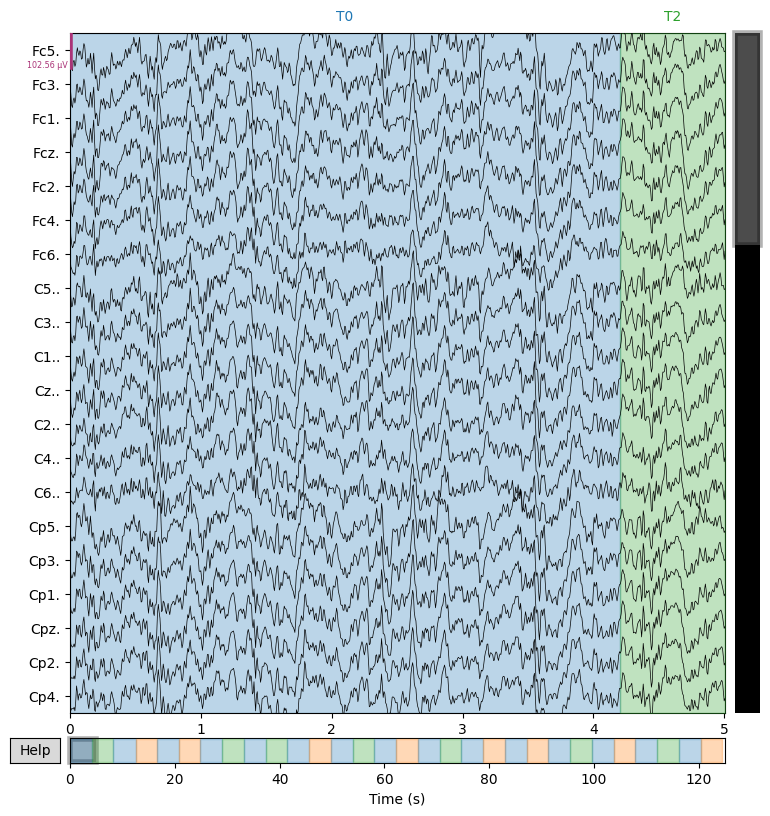

Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


/var/folders/7f/1v0f7cl50jg75rsqwct5fkbm0000gn/T/ipykernel_58522/2130040821.py:3: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig_psd = raw.compute_psd(fmax=50.0).plot()
/Users/satwik/Workspace/Data Privacy/.brain/lib/python3.9/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


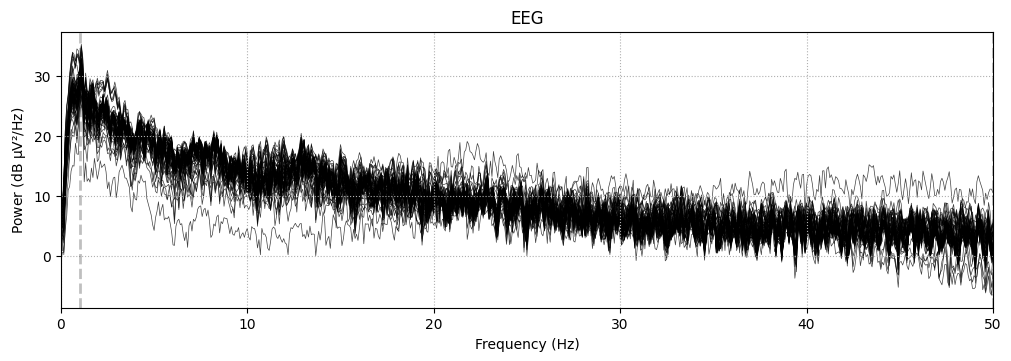

In [17]:
print("Generating visualizations...")
fig_time = raw.plot(duration=5.0, n_channels=20, scalings='auto', title="Filtered EEG Signals (5-Second Window)", block=False)
fig_psd = raw.compute_psd(fmax=50.0).plot()
plt.show()

### Independent Component Analysis

ICA can help isolate and remove artifacts by decomposing the EEG signals into independent components.

In [19]:
print("Standardizing PhysioNet channel names...")
# This single built-in function fixes the dots and the capitalization perfectly
eegbci.standardize(raw)

print("Applying standard 1005 montage...")
montage = mne.channels.make_standard_montage('standard_1005')

raw.set_montage(montage)

Standardizing PhysioNet channel names...
Applying standard 1005 montage...


<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.9 MB, data loaded>

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 0.2s.


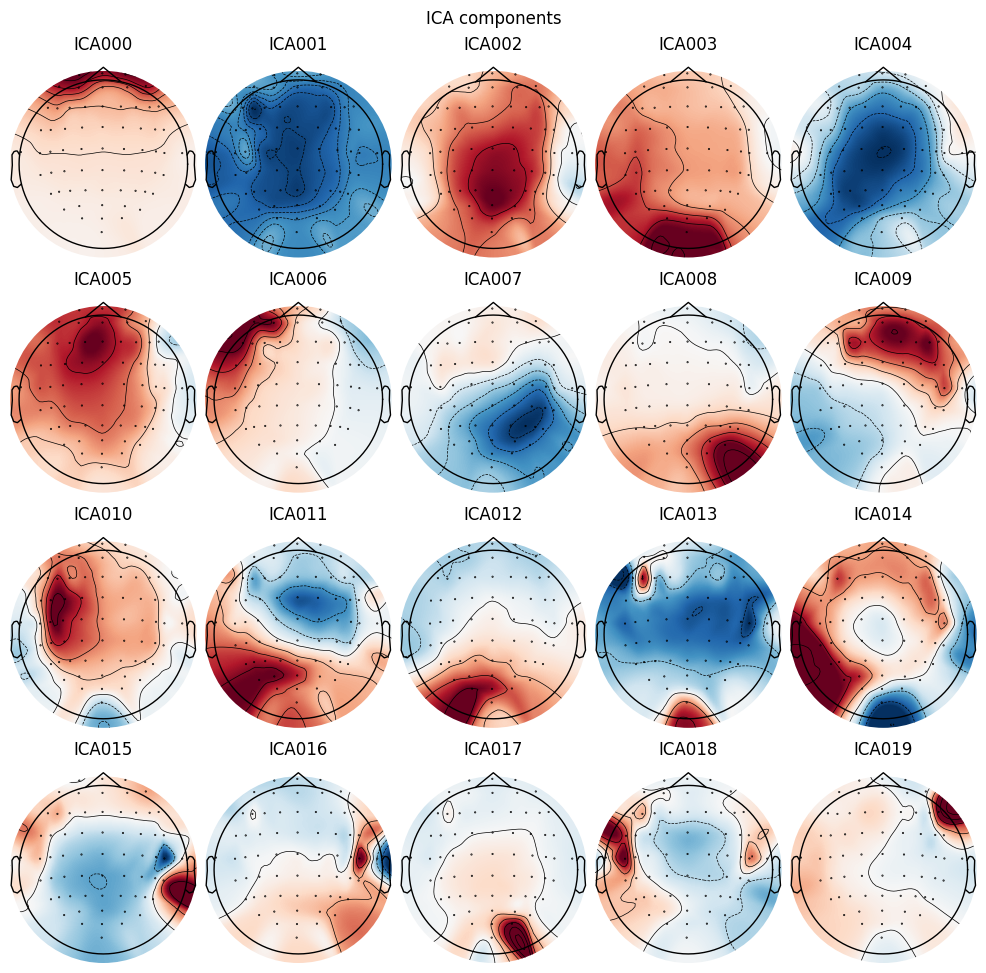

Creating RawArray with float64 data, n_channels=20, n_times=20000
    Range : 0 ... 19999 =      0.000 ...   124.994 secs
Ready.


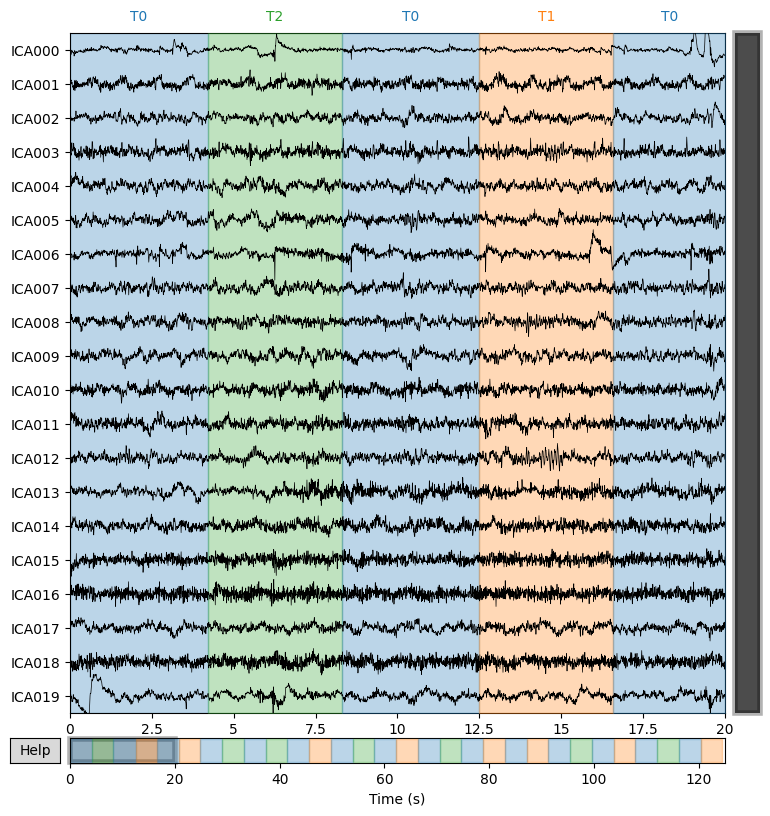

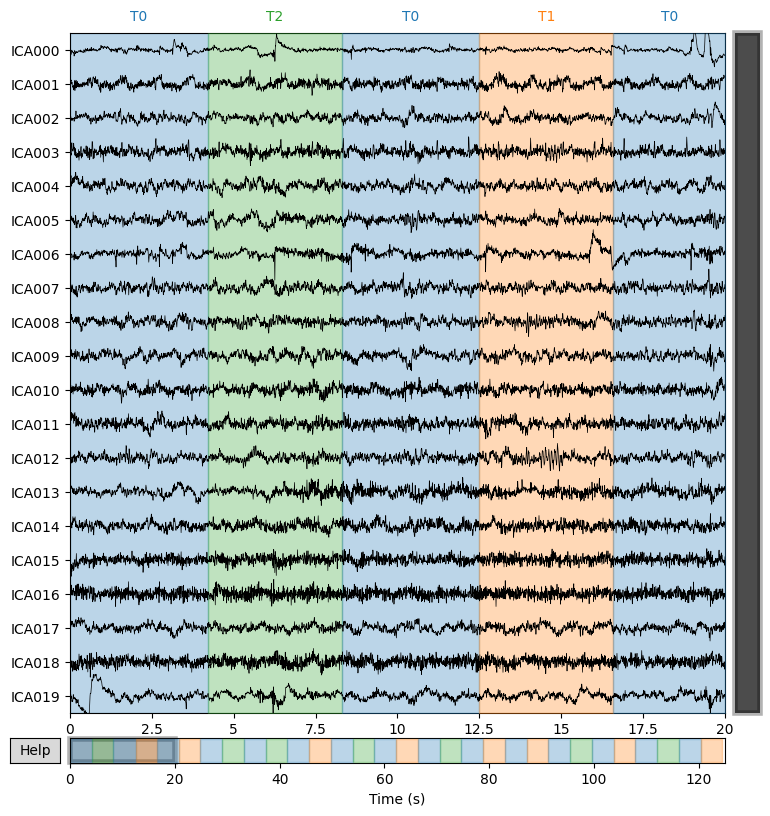

In [20]:
ica = ICA(n_components=20, random_state=97, max_iter=800)
ica.fit(raw)

ica.plot_components()
ica.plot_sources(raw, block=True)